# 03 — N-tuple network with TD(0) on afterstates

Following Szubert & Jaśkowski (CIG 2014). The value function is a sum of small lookup tables indexed by patterns of cells; the patterns are augmented with the 8-fold dihedral symmetry group, so each board lookup involves ~32 table reads (vectorized via numpy fancy-indexing).

**Patterns** (S&J 2014 layout): two 6-tuples (`pattern_a`, `pattern_b`, axe shapes covering the top two rows) plus two 4-tuples (`pattern_c` = top row, `pattern_d` = 2×2 corner square).

**Memory.** Each 6-tuple needs 16⁶ × 4 B = 64 MiB; total ≈ 128 MiB across patterns.

**Update rule (afterstates).** With $a_t$ the afterstate at time $t$ (deterministic outcome of the move, *before* the random spawn), $r_{t+1}$ the next greedy reward and $a_{t+1}$ the next afterstate:

$$ V(a_t) \leftarrow V(a_t) + \alpha \cdot \big( r_{t+1} + V(a_{t+1}) - V(a_t) \big). $$

Action selection is greedy on $r(s,a) + V(\text{afterstate}(s,a))$ over legal moves.

Runs ~10 k episodes (~30-60 min). Bump `EPISODES` to 100_000+ for full convergence.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import set_seed, CKPT_DIR, LOG_DIR, EVAL_DIR
from src.agents.ntuple import NTupleAgent, NTupleNetwork, PATTERNS
from src.training.train_ntuple import train_ntuple
from src.eval.evaluate import run_eval, save_eval

set_seed(42)
sns.set_theme()
plt.rcParams['figure.dpi'] = 110

NT_CKPT_DIR = CKPT_DIR / 'ntuple'
NT_LOG = LOG_DIR / 'ntuple.csv'

print('patterns:', [(len(p), p) for p in PATTERNS])
print('weight tables:', [16 ** len(p) for p in PATTERNS], '→',
      f'{sum(16 ** len(p) for p in PATTERNS) * 4 / 1e6:.1f} MB')

patterns: [(6, ((0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1))), (6, ((1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1))), (4, ((0, 0), (0, 1), (0, 2), (0, 3))), (4, ((0, 0), (0, 1), (1, 0), (1, 1)))]
weight tables: [16777216, 16777216, 65536, 65536] → 134.7 MB


In [2]:
EPISODES = 10_000

agent = NTupleAgent(alpha=0.1)
print(f'effective per-weight α = {agent.alpha:.4f}  (base α = {agent.alpha_base})')
ckpt_path = train_ntuple(agent, episodes=EPISODES, log_path=NT_LOG,
                          ckpt_dir=NT_CKPT_DIR, ckpt_every=max(EPISODES // 5, 100),
                          verbose=True)
print('saved:', ckpt_path)

effective per-weight α = 0.0042  (base α = 0.1)


ep    500 | avg100    976.4 | max_tile   512 | alpha 0.1


ep   1000 | avg100   1282.5 | max_tile   256 | alpha 0.1


ep   1500 | avg100   1502.7 | max_tile   256 | alpha 0.1


ep   2000 | avg100   1829.4 | max_tile  1024 | alpha 0.1


...

ep   8500 | avg100   3101.4 | max_tile  2048 | alpha 0.1


ep   9000 | avg100   3168.7 | max_tile  2048 | alpha 0.1


ep   9500 | avg100   3254.4 | max_tile  1024 | alpha 0.1


ep  10000 | avg100   3254.0 | max_tile  2048 | alpha 0.1


saved: /Users/florianrobrecht/Documents/006_GitHub/Machine-Learning-2/Assignment 5/data/checkpoints/ntuple/latest.npz


## Training curves

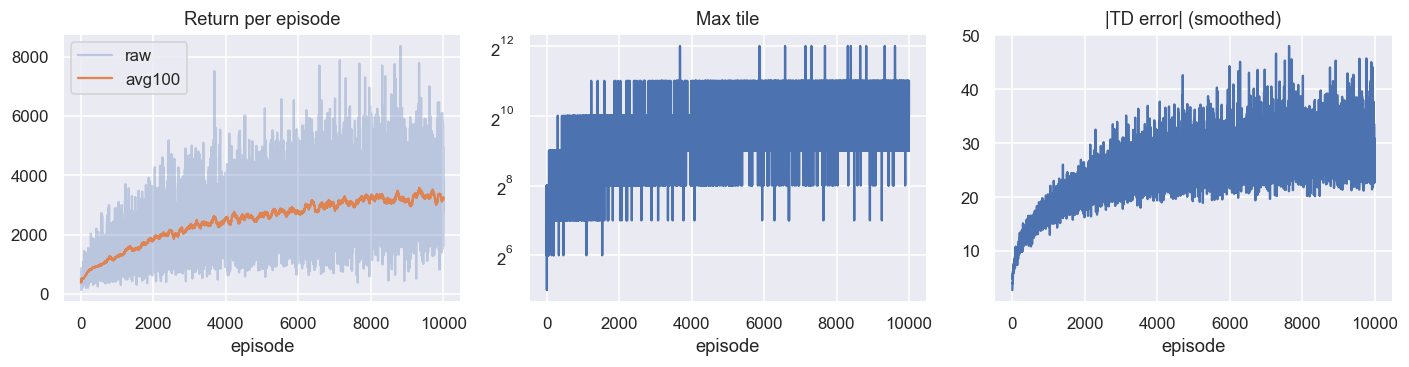

In [3]:
log_df = pd.read_csv(NT_LOG)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(log_df['episode'], log_df['return'], alpha=0.3, label='raw')
axes[0].plot(log_df['episode'], log_df['return'].rolling(100, min_periods=1).mean(), label='avg100')
axes[0].set_title('Return per episode'); axes[0].legend()
axes[1].plot(log_df['episode'], log_df['max_tile']); axes[1].set_yscale('log', base=2); axes[1].set_title('Max tile')
axes[2].plot(log_df['episode'], pd.to_numeric(log_df['loss_or_td_error'], errors='coerce'))
axes[2].set_title('|TD error| (smoothed)')
for ax in axes: ax.set_xlabel('episode')
fig.tight_layout()

## Reload + greedy eval

In [4]:
eval_agent = NTupleAgent(alpha=0.1)
eval_agent.load(ckpt_path)
metrics = run_eval(eval_agent, n_games=300, seed=0, train_log=NT_LOG)
save_eval(metrics, EVAL_DIR / 'eval_ntuple.json')
metrics

{'agent': 'ntuple',
 'n_games': 300,
 'mean_score': 3270.1666666666665,
 'median_score': 3178.0,
 'max_score': 7414,
 'mean_max_tile': 1221.9733333333334,
 'max_max_tile': 4096,
 'pct_reaching': {'512': 0.9833333333333333,
  '1024': 0.87,
  '2048': 0.25,
  '4096': 0.006666666666666667,
  '8192': 0.0},
 'mean_steps': 1086.8033333333333,
 'episodes_to_first_1024': 307,
 'episodes_to_first_2048': 1231}